In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdate
import matplotlib.ticker as mtick

from notebook_utils import timeseries_rel
from otter import water_balance

sns.set_theme(context="notebook", style="darkgrid", palette='bright')

In [2]:
geo_area_map = {
    "(-123.46380833083272, 45.089694203862486)": "Willamette Valley, OR",
    "(-97.47756073604941, 47.1336925379081)": "SE North Dakota",
    "(-115.61696276681141, 33.09177438923619)": "Imperial Valley, CA",
    "(-96.70306085261703, 28.545428715671637)": "SE Coastline, TX"
}

rooting_depth_map = {
    "(-123.46380833083272, 45.089694203862486)": 1, # Grass Hay
    "(-97.47756073604941, 47.1336925379081)": 1.7, # Corn
    "(-115.61696276681141, 33.09177438923619)": 2, # Alfalfa
    "(-96.70306085261703, 28.545428715671637)": 1.7 # Cotton
}

## Calculations

In [3]:
aws = pd.read_csv("../data/peff_points_aws_ts.csv")[["point", "aws", "aws_max", "time", "peff", "etaw", "cn"]]
aws["time"] = pd.to_datetime(aws["time"])

aws

,point,aws,aws_max,time,peff,etaw,cn
0,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2016-01-01,0.000,0.0,78.0
1,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2016-01-02,0.739,0.0,78.0
2,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2016-01-03,0.450,0.0,78.0
3,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2016-01-04,0.091,0.0,78.0
4,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2016-01-05,0.148,0.0,78.0
...,...,...,...,...,...,...,...
30679,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-27,-242.000,0.0,88.0
30680,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-28,-242.000,0.0,88.0
30681,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-29,-242.000,0.0,88.0
30682,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-30,-242.000,0.0,88.0


In [4]:
ts = pd.read_csv("../data/peff_points_var_ts.csv")
ts["time"] = pd.to_datetime(ts["time"])
ts.head()

,point,time,et,eto,pr
0,"(-123.46380833083272, 45.089694203862486)",2016-01-01,0.420,1.025,0.000
1,"(-123.46380833083272, 45.089694203862486)",2016-01-02,0.303,0.741,0.739
2,"(-123.46380833083272, 45.089694203862486)",2016-01-03,0.149,0.365,10.347
3,"(-123.46380833083272, 45.089694203862486)",2016-01-04,0.091,0.224,5.776
4,"(-123.46380833083272, 45.089694203862486)",2016-01-05,0.148,0.365,0.915


In [5]:
data = aws.merge(ts, how="left", on=["point", "time"])
data["Location"] = data["point"].map(geo_area_map)
data["root_depth"] = data["point"].map(rooting_depth_map)
data = data.query("time >= '2022-01-01' and time <= '2022-12-31'").copy()
data

,point,aws,aws_max,time,peff,etaw,cn,et,eto,pr,Location,root_depth
2192,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-01,0.000,0.0,78.0,0.084,0.153,0.000,"Willamette Valley, OR",1.0
2193,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-02,0.756,0.0,78.0,0.555,1.007,45.017,"Willamette Valley, OR",1.0
2194,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-03,0.086,0.0,78.0,0.086,0.157,10.098,"Willamette Valley, OR",1.0
2195,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-04,0.182,0.0,78.0,0.182,0.330,9.402,"Willamette Valley, OR",1.0
2196,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-05,0.409,0.0,78.0,0.409,0.741,22.526,"Willamette Valley, OR",1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
30679,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-27,-242.000,0.0,88.0,0.157,0.548,0.000,SE North Dakota,1.7
30680,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-28,-242.000,0.0,88.0,0.031,0.110,0.000,SE North Dakota,1.7
30681,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-29,-242.000,0.0,88.0,0.000,0.000,0.000,SE North Dakota,1.7
30682,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-30,-242.000,0.0,88.0,0.012,0.043,0.000,SE North Dakota,1.7


In [6]:
def calc_wb(group: pd.DataFrame):
    aws_max = group["aws"].values[0]
    dru, drl, perc, dperc, ro, etaw,\
            peff, et = water_balance.do_wb_interp(
                aws_max=aws_max,
                aws_u_ts=group["aws"].to_numpy(),
                cn_ts=group["cn"].to_numpy(),
                et_ts=group["et"].to_numpy(),
                eto_ts=group["eto"].to_numpy(),
                pr_ts=group["pr"].to_numpy()
            )
    group["dru"] = dru
    group["drl"] = drl
    group["perc"] = perc
    group["dperc"] = dperc
    group["ro"] = ro

    return group

In [7]:
data = data.groupby(["point", "aws"], group_keys=False).apply(calc_wb)

/tmp/ipykernel_2106332/261313326.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby(["point", "aws"], group_keys=False).apply(calc_wb)


In [8]:
data["fc_wp"] = data["aws_max"].div(2.4)
data["fc_wp"] = data["fc_wp"] * data["root_depth"]
data

,point,aws,aws_max,time,peff,etaw,cn,et,eto,pr,Location,root_depth,dru,drl,perc,dperc,ro,fc_wp
2192,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-01,0.000,0.0,78.0,0.084,0.153,0.000,"Willamette Valley, OR",1.0,100.000000,0.0,0.0,0.0,0.000000,65.833333
2193,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-02,0.756,0.0,78.0,0.555,1.007,45.017,"Willamette Valley, OR",1.0,64.741592,0.0,0.0,0.0,9.203594,65.833333
2194,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-03,0.086,0.0,78.0,0.086,0.157,10.098,"Willamette Valley, OR",1.0,54.729595,0.0,0.0,0.0,0.000000,65.833333
2195,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-04,0.182,0.0,78.0,0.182,0.330,9.402,"Willamette Valley, OR",1.0,45.509594,0.0,0.0,0.0,0.000000,65.833333
2196,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-05,0.409,0.0,78.0,0.409,0.741,22.526,"Willamette Valley, OR",1.0,24.234339,0.0,0.0,0.0,0.841744,65.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30679,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-27,-242.000,0.0,88.0,0.157,0.548,0.000,SE North Dakota,1.7,559.040344,0.0,0.0,0.0,0.000000,281.916667
30680,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-28,-242.000,0.0,88.0,0.031,0.110,0.000,SE North Dakota,1.7,559.071350,0.0,0.0,0.0,0.000000,281.916667
30681,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-29,-242.000,0.0,88.0,0.000,0.040,0.000,SE North Dakota,1.7,559.071350,0.0,0.0,0.0,0.000000,281.916667
30682,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-30,-242.000,0.0,88.0,0.012,0.043,0.000,SE North Dakota,1.7,559.083313,0.0,0.0,0.0,0.000000,281.916667


In [9]:
points_max = data.groupby(["point", "Location", "aws"])[["peff", "dru", "drl", "perc", "dperc", "ro"]].agg("max").reset_index()
points_max

,point,Location,aws,peff,dru,drl,perc,dperc,ro
0,"(-115.61696276681141, 33.09177438923619)","Imperial Valley, CA",100.0,16.715000,100.0,0.0,0.000000,0.000000,2.887808
1,"(-115.61696276681141, 33.09177438923619)","Imperial Valley, CA",350.0,16.715000,350.0,0.0,0.000000,0.000000,2.887808
2,"(-115.61696276681141, 33.09177438923619)","Imperial Valley, CA",640.0,-254.285004,640.0,0.0,0.000000,0.000000,2.887808
3,"(-123.46380833083272, 45.089694203862486)","Willamette Valley, OR",100.0,17.981001,100.0,0.0,41.005653,41.005653,16.252346
4,"(-123.46380833083272, 45.089694203862486)","Willamette Valley, OR",350.0,-155.332001,350.0,0.0,28.895828,28.895828,16.252346
5,"(-123.46380833083272, 45.089694203862486)","Willamette Valley, OR",640.0,-445.332001,640.0,0.0,0.000000,0.000000,16.252346
6,"(-96.70306085261703, 28.545428715671637)","SE Coastline, TX",100.0,29.674000,100.0,0.0,26.726761,26.726761,43.514477
7,"(-96.70306085261703, 28.545428715671637)","SE Coastline, TX",350.0,29.674000,350.0,0.0,0.000000,0.000000,43.514477
8,"(-96.70306085261703, 28.545428715671637)","SE Coastline, TX",640.0,-178.326004,640.0,0.0,0.000000,0.000000,43.514477
9,"(-97.47756073604941, 47.1336925379081)",SE North Dakota,100.0,21.389999,100.0,0.0,14.051196,14.051196,29.780334


In [10]:
def calc_rwd(group: pd.DataFrame):
    point = group["point"].values[0]
    aws = group["aws"].values[0]
    
    drmax = points_max[(points_max["point"] == point) & (points_max["aws"] == aws)]["dru"].values[0]

    rwd = (drmax - group["dru"]) / drmax

    group["rwd"] = rwd

    return group

In [11]:
data = data.groupby(["point", "aws"], group_keys=False).apply(calc_rwd)
data["v_aws"] = data["aws"] * data["root_depth"]
data

/tmp/ipykernel_2106332/308078965.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby(["point", "aws"], group_keys=False).apply(calc_rwd)


,point,aws,aws_max,time,peff,etaw,cn,et,eto,pr,Location,root_depth,dru,drl,perc,dperc,ro,fc_wp,rwd,v_aws
2192,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-01,0.000,0.0,78.0,0.084,0.153,0.000,"Willamette Valley, OR",1.0,100.000000,0.0,0.0,0.0,0.000000,65.833333,0.000000,100.0
2193,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-02,0.756,0.0,78.0,0.555,1.007,45.017,"Willamette Valley, OR",1.0,64.741592,0.0,0.0,0.0,9.203594,65.833333,0.352584,100.0
2194,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-03,0.086,0.0,78.0,0.086,0.157,10.098,"Willamette Valley, OR",1.0,54.729595,0.0,0.0,0.0,0.000000,65.833333,0.452704,100.0
2195,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-04,0.182,0.0,78.0,0.182,0.330,9.402,"Willamette Valley, OR",1.0,45.509594,0.0,0.0,0.0,0.000000,65.833333,0.544904,100.0
2196,"(-123.46380833083272, 45.089694203862486)",100.0,158.0,2022-01-05,0.409,0.0,78.0,0.409,0.741,22.526,"Willamette Valley, OR",1.0,24.234339,0.0,0.0,0.0,0.841744,65.833333,0.757657,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30679,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-27,-242.000,0.0,88.0,0.157,0.548,0.000,SE North Dakota,1.7,559.040344,0.0,0.0,0.0,0.000000,281.916667,0.126499,1088.0
30680,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-28,-242.000,0.0,88.0,0.031,0.110,0.000,SE North Dakota,1.7,559.071350,0.0,0.0,0.0,0.000000,281.916667,0.126451,1088.0
30681,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-29,-242.000,0.0,88.0,0.000,0.040,0.000,SE North Dakota,1.7,559.071350,0.0,0.0,0.0,0.000000,281.916667,0.126451,1088.0
30682,"(-97.47756073604941, 47.1336925379081)",640.0,398.0,2022-12-30,-242.000,0.0,88.0,0.012,0.043,0.000,SE North Dakota,1.7,559.083313,0.0,0.0,0.0,0.000000,281.916667,0.126432,1088.0


## Figures

In [21]:
data = data.query("Location == 'Willamette Valley, OR'")

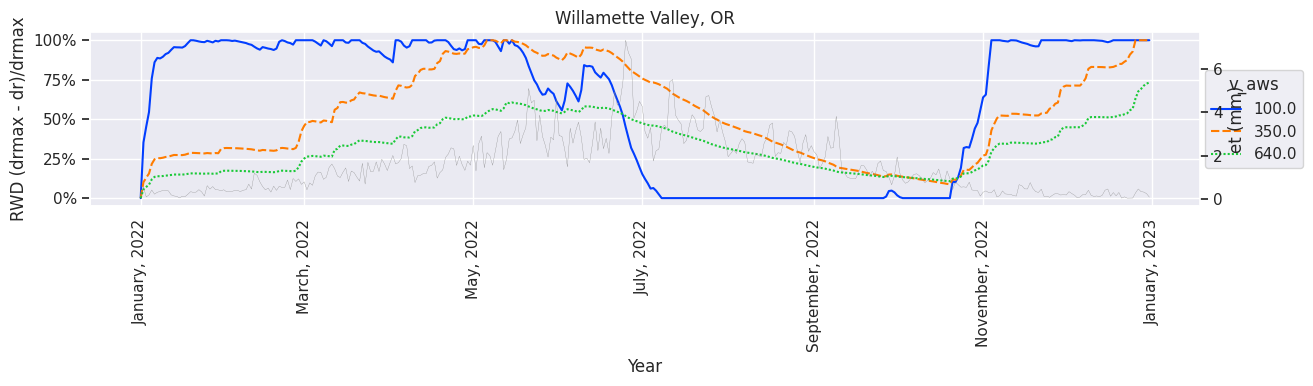

In [22]:
g = timeseries_rel(data=data, x="time", y="rwd", share_legend=False,
                    row="Location", hue="v_aws", palette="bright", style="v_aws",
                   twin_y="et", twin_y_share_y=False, twin_y_ylabels="et (mm)",
                    title_template={"row_template": "{row_name}"},
                    facet_kwargs={"sharex": False, "sharey": False, "aspect":3.2, "height": 4.2}, as_percent=True,
                    x_formatter=mdate.DateFormatter("%B, %Y"));
g.tight_layout();
# sns.move_legend(
#     g, "lower center",
#     bbox_to_anchor=(.5, 1), ncol=5, title="Varied AWS (AWS * root_depth)", frameon=True,
# );
g.set_ylabels("RWD (drmax - dr)/drmax");
g.set_xlabels("Year");

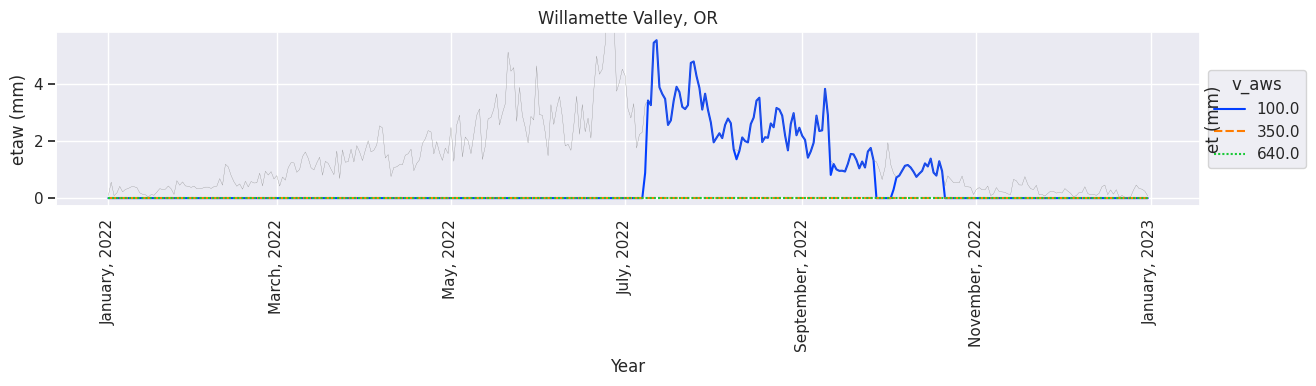

In [23]:
ax = timeseries_rel(data=data, x="time", y="etaw", share_legend=False,
                    twin_y="et", twin_y_ylabels="et (mm)", twin_y_share_y=True,
                    row="Location", hue="v_aws", palette="bright", style="v_aws",
                    title_template={"row_template": "{row_name}"},
                    facet_kwargs={"sharex": False, "sharey": False, "aspect":3.2, "height": 4.2},
                    x_formatter=mdate.DateFormatter("%B, %Y"));
ax.tight_layout();
ax.set_ylabels("etaw (mm)");
ax.set_xlabels("Year");

In [34]:
csum_1 = data.query("aws == 100").set_index(["time", "Location"])[["etaw", "et"]].cumsum()
csum_1["aws"] = 100

csum_2 = data.query("aws == 350").set_index(["time", "Location"])[["etaw", "et"]].cumsum()
csum_2["aws"] = 350

csum_3 = data.query("aws == 640").set_index(["time", "Location"])[["etaw", "et"]].cumsum()
csum_3["aws"] = 640


csum_data = pd.concat([csum_1, csum_2, csum_3]).reset_index()
csum_data

,time,Location,etaw,et,aws
0,2022-01-01,"Willamette Valley, OR",0.0,0.084,100
1,2022-01-02,"Willamette Valley, OR",0.0,0.639,100
2,2022-01-03,"Willamette Valley, OR",0.0,0.725,100
3,2022-01-04,"Willamette Valley, OR",0.0,0.907,100
4,2022-01-05,"Willamette Valley, OR",0.0,1.316,100
...,...,...,...,...,...
1090,2022-12-27,"Willamette Valley, OR",0.0,572.356,640
1091,2022-12-28,"Willamette Valley, OR",0.0,572.688,640
1092,2022-12-29,"Willamette Valley, OR",0.0,573.001,640
1093,2022-12-30,"Willamette Valley, OR",0.0,573.242,640


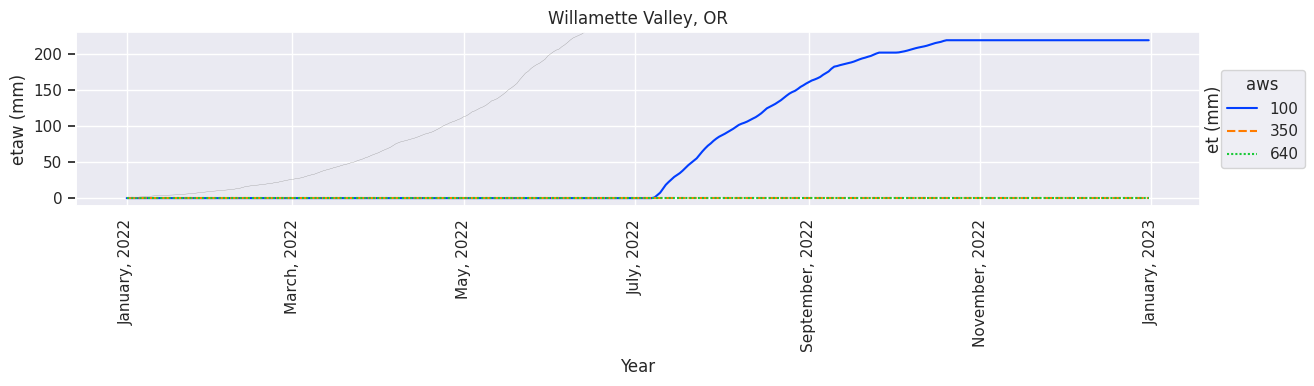

In [36]:
ax = timeseries_rel(data=csum_data, x="time", y="etaw", share_legend=False,
                    twin_y="et", twin_y_ylabels="et (mm)", twin_y_share_y=True,
                    row="Location", hue="aws", palette="bright", style="aws",
                    title_template={"row_template": "{row_name}"},
                    facet_kwargs={"sharex": False, "sharey": False, "aspect":3.2, "height": 4.2},
                    x_formatter=mdate.DateFormatter("%B, %Y"));
ax.tight_layout();
ax.set_ylabels("etaw (mm)");
ax.set_xlabels("Year");

In [38]:
csum_1_pr = data.query("aws == 100").set_index(["time", "Location"])[["pr", "peff"]].cumsum()
csum_1_pr["aws"] = 100

csum_2_pr = data.query("aws == 350").set_index(["time", "Location"])[["pr", "peff"]].cumsum()
csum_2_pr["aws"] = 350

csum_3_pr = data.query("aws == 640").set_index(["time", "Location"])[["pr", "peff"]].cumsum()
csum_3_pr["aws"] = 640


csum_data_pr = pd.concat([csum_1_pr, csum_2_pr, csum_3_pr]).reset_index()
csum_data_pr

,time,Location,pr,peff,aws
0,2022-01-01,"Willamette Valley, OR",0.000,0.000000,100
1,2022-01-02,"Willamette Valley, OR",45.017,0.756000,100
2,2022-01-03,"Willamette Valley, OR",55.115,0.842000,100
3,2022-01-04,"Willamette Valley, OR",64.517,1.024000,100
4,2022-01-05,"Willamette Valley, OR",87.043,1.433000,100
...,...,...,...,...,...
1090,2022-12-27,"Willamette Valley, OR",1058.126,-173429.531006,640
1091,2022-12-28,"Willamette Valley, OR",1068.490,-173911.199005,640
1092,2022-12-29,"Willamette Valley, OR",1081.949,-174392.886017,640
1093,2022-12-30,"Willamette Valley, OR",1090.645,-174874.645020,640


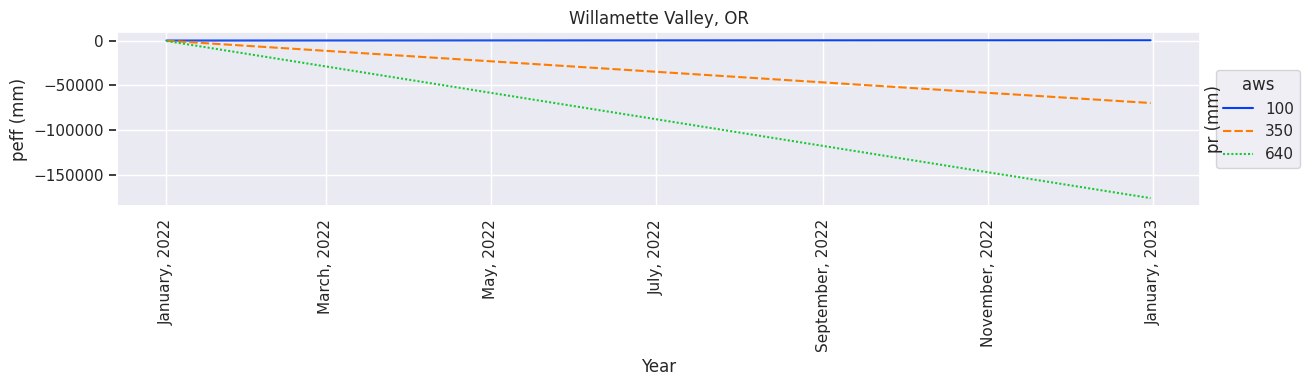

In [40]:
ax = timeseries_rel(data=csum_data_pr, x="time", y="peff", share_legend=False,
                    twin_y="pr", twin_y_ylabels="pr (mm)", twin_y_share_y=True,
                    row="Location", hue="aws", palette="bright", style="aws",
                    title_template={"row_template": "{row_name}"},
                    facet_kwargs={"sharex": False, "sharey": False, "aspect":3.2, "height": 4.2},
                    x_formatter=mdate.DateFormatter("%B, %Y"));
ax.tight_layout();
ax.set_ylabels("peff (mm)");
ax.set_xlabels("Year");